# 3. Reserve-Policy Tradeoff and Daily Stability

This notebook runs the auction-replay layer for the reserve/floor policy catalog and regenerates the replay/guardrail figures used in the paper:

- **Guardrail policy matrix:** policy-by-screen pass/fail view,
- **Reserve-policy tradeoff frontier:** yield lift versus intervention breadth,
- **Shortlist daily stability:** day-by-day replay lift for shortlisted candidates.

The notebook sits after the nuisance-model diagnostic because the paper first checks data quality and learned-component quality, then turns to the first substantive marketplace decision question: which reserve/floor policies are worth considering at all?



## What This Notebook Creates

Inputs from setup:

- `artifacts/workspace/data/processed/season2_bid_opportunity_panel/*.parquet`
- `artifacts/workspace/metadata/reserve_policy_price_landscape.csv`
- `artifacts/workspace/metadata/reserve_policy_registry.csv`

Generated analysis artifacts:

- `metadata/reserve_policy_effects.csv`
- `metadata/reserve_policy_daily_effects.csv`
- `metadata/reserve_policy_guardrails.csv`
- `metadata/reserve_policy_guardrail_matrix.csv`
- `metadata/reserve_policy_candidate_handoff.csv`
- `metadata/reserve_policy_shortlist.csv`
- corresponding table copies for the main replay outputs under `tables/`

Generated paper figures:

- `artifacts/figures/06_guardrail_policy_matrix.png`
- `artifacts/figures/06_reserve_policy_tradeoff_frontier.png`
- `artifacts/figures/06_shortlist_daily_stability.png`

The replay is deterministic conditional on the Season 2 panel and the policy catalog. It does not estimate bidder response, budget pacing response, or equilibrium effects. Those are handled later through OPE diagnostics, robustness checks, Season 3 validation, and validation-design analysis.



## Replay Setup

A reserve/floor policy maps each logged bid opportunity to a candidate floor. The replay contract then asks a mechanical counterfactual question: holding the logged bid fixed, would the impression still have been retained under the candidate floor?

For bid opportunity $i$, let $b_i$ be the logged bid, $f_i$ the logged floor, and $g(i)$ the candidate floor under policy $g$. The replay retention indicator is

$$
R_i(g) = \mathbf{1}\{\mathrm{filled}_i=1\}\mathbf{1}\{b_i \ge g(i)\}.
$$

The replayed payment is

$$
Y_i(g) = R_i(g)\max\{\mathrm{pay\_price}_i, g(i)\}.
$$

This construction is useful for screening because it exposes yield/fill tradeoffs under a clearly defined finite-population estimand. It is not a claim that bidders would submit the same bids after a real policy launch.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from auction_replay import PolicyReplayAnalyzer
from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths
from data_access import Workspace
from figures import FigureRenderer
from guardrails import ReservePolicyGuardrails
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger


In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)

season2_shards = sorted(workspace.season2_panel_dir.glob("season2_panel_*.parquet"))
if not season2_shards:
    raise FileNotFoundError(
        f"Run notebooks/0_setup.ipynb first. Missing Season 2 shards under {workspace.season2_panel_dir}"
    )

price_landscape_path = workspace.metadata_dir / "reserve_policy_price_landscape.csv"
if not price_landscape_path.exists():
    raise FileNotFoundError(f"Run notebooks/0_setup.ipynb first. Missing: {price_landscape_path}")

print(f"Found {len(season2_shards):,} Season 2 replay shard(s).")
print(f"Price landscape: {price_landscape_path.relative_to(REPO_ROOT)}")


Found 7 Season 2 replay shard(s).
Price landscape: artifacts/workspace/metadata/reserve_policy_price_landscape.csv


## Reconstruct the Policy Catalog

The setup notebook computes positive-floor quantiles from the Season 2 panel. Those quantiles define the catalog's q25, q50, and q75 threshold policies. Reconstructing the catalog from the saved quantiles keeps this notebook independent of the full combined panel: the replay analyzer only needs the per-day shards.


In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}

catalog = ReservePolicyCatalog(price_quantiles)
policy_registry = catalog.registry()

print("Reserve/floor quantiles used by the catalog:")
for name, value in price_quantiles.items():
    print(f"  {name}: {value:.2f}")

policy_registry[["policy_number", "policy_id", "policy_family", "floor_rule"]]


Reserve/floor quantiles used by the catalog:
  q25: 10.00
  q50: 50.00
  q75: 100.00


,policy_number,policy_id,policy_family,floor_rule
0,P0,logged_floor_status_quo,baseline,logged
1,P1,uniform_raise_05pct,uniform_percent,logged * 1.05
2,P2,uniform_raise_10pct,uniform_percent,logged * 1.10
3,P3,uniform_raise_15pct,uniform_percent,logged * 1.15
4,P4,uniform_raise_20pct,uniform_percent,logged * 1.20
5,P5,uniform_raise_30pct,uniform_percent,logged * 1.30
6,P6,add_5_all_floors,absolute_increment,logged + 5
7,P7,add_10_all_floors,absolute_increment,logged + 10
8,P8,add_20_all_floors,absolute_increment,logged + 20
9,P9,min_positive_floor_q25,minimum_positive_floor,"max(logged, 10.00) if logged > 0"


The catalog deliberately includes simple baselines and more selective rules. Uniform and additive policies answer whether broad floor increases are attractive. Minimum-floor policies answer whether low positive floors should be lifted to a common threshold. Margin-gated policies answer whether the floor should only be raised when the logged bid is sufficiently above the logged floor. The last group is especially important for marketplace decision support because it encodes a simple operational intuition: raise floors where observed bid margins indicate room to move, and avoid changing auctions with thin margins.


## Run Auction Replay and Guardrails

Set `RUN_REPLAY = True` to recompute replay from the Season 2 shards. This is the normal setting for a fresh run. Set it to `False` only when the replay artifacts already exist and you only want to rerender the figures.

The replay analyzer streams over per-day parquet shards. For each policy and day it computes retained impressions, replayed yield, retained clicks, retained conversions, and retained value proxy. The guardrail layer then applies the launch screens used in the paper: positive yield gain, aggregate fill retention, daily fill retention, click retention, conversion retention, value-proxy retention, and daily yield stability.


In [5]:
RUN_REPLAY = True

if RUN_REPLAY:
    analyzer = PolicyReplayAnalyzer(workspace, catalog, progress=progress)
    effects, daily = analyzer.evaluate()
else:
    effects = repository.read_csv("reserve_policy_effects.csv")
    daily = repository.read_csv("reserve_policy_daily_effects.csv")
    print("Refreshing guardrail artifacts from existing replay outputs.")
    ReservePolicyGuardrails(workspace).evaluate(effects, daily)

print(f"Aggregate replay rows: {len(effects):,}")
print(f"Daily replay rows: {len(daily):,}")



[     0.0s] Starting: auction replay for 19 reserve/floor policies
[     0.0s] Replaying policies on season-two shard 1/7: season2_panel_20130606.parquet.
[    13.2s] Replaying policies on season-two shard 2/7: season2_panel_20130607.parquet.
[    27.9s] Replaying policies on season-two shard 3/7: season2_panel_20130608.parquet.
[    35.0s] Replaying policies on season-two shard 4/7: season2_panel_20130609.parquet.
[    50.3s] Replaying policies on season-two shard 5/7: season2_panel_20130610.parquet.
[    57.8s] Replaying policies on season-two shard 6/7: season2_panel_20130611.parquet.
[    64.5s] Replaying policies on season-two shard 7/7: season2_panel_20130612.parquet.
[    70.9s] Finished: auction replay; evaluated 19 policies across 7 shard(s)
Aggregate replay rows: 19
Daily replay rows: 133


In [6]:
registry_labels = policy_registry[["policy_id", "policy_number", "policy_label"]]
effects_display = effects.merge(registry_labels, on="policy_id", how="left")
summary_cols = [
    "policy_number",
    "policy_label",
    "policy_id",
    "pct_delta_yield_per_opportunity_vs_baseline",
    "retained_impression_share",
    "click_retention",
    "conversion_retention",
    "value_proxy_retention",
    "floor_changed_share",
]
(
    effects_display[summary_cols]
    .sort_values("pct_delta_yield_per_opportunity_vs_baseline", ascending=False)
    .head(10)
)


,policy_number,policy_label,policy_id,pct_delta_yield_per_opportunity_vs_baseline,retained_impression_share,click_retention,conversion_retention,value_proxy_retention,floor_changed_share
0,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,0.476604,1.000000,1.000000,1.0,1.000000,0.750733
1,P11,Min Positive Floor Q75,min_positive_floor_q75,0.355075,1.000000,1.000000,1.0,1.000000,0.635903
2,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,0.101179,1.000000,1.000000,1.0,1.000000,0.475775
3,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,0.101179,1.000000,1.000000,1.0,1.000000,0.475775
4,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,0.097883,1.000000,1.000000,1.0,1.000000,0.991635
5,P8,Add 20 All Floors,add_20_all_floors,0.097433,0.999706,0.999885,1.0,0.999921,1.000000
6,P10,Min Positive Floor Q50,min_positive_floor_q50,0.072978,1.000000,1.000000,1.0,1.000000,0.360944
7,P5,Uniform Raise 30Pct,uniform_raise_30pct,0.069190,0.997866,0.997136,1.0,0.998022,0.885169
8,P4,Uniform Raise 20Pct,uniform_raise_20pct,0.044008,0.999159,0.998052,1.0,0.998655,0.885169
9,P15,Margin Gap 50 Add 10,margin_gap_50_add_10,0.040727,1.000000,1.000000,1.0,1.000000,0.999294


The table above is the aggregate replay ranking. The yield column is a percentage change relative to the logged-floor baseline. Retained-impression share is measured relative to the baseline's observed filled impressions. A high yield lift is not enough by itself: policies also need to preserve delivery and downstream proxy value to remain credible candidates for deeper analysis.


In [7]:
guardrails = repository.read_csv("reserve_policy_guardrails.csv")
shortlist = repository.read_csv("reserve_policy_shortlist.csv")

shortlist_display = shortlist.merge(registry_labels, on="policy_id", how="left")
shortlist_cols = [
    "policy_number",
    "policy_label",
    "policy_id",
    "pct_delta_yield_per_opportunity_vs_baseline",
    "min_daily_pct_yield_delta",
    "retained_impression_share",
    "min_daily_retained_impression_share",
    "guardrails_passed",
    "decision_band",
]
shortlist_display[shortlist_cols].sort_values("pct_delta_yield_per_opportunity_vs_baseline", ascending=False)


,policy_number,policy_label,policy_id,pct_delta_yield_per_opportunity_vs_baseline,min_daily_pct_yield_delta,retained_impression_share,min_daily_retained_impression_share,guardrails_passed,decision_band
0,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,0.476604,0.434379,1.000000,1.000000,7,promising_for_deeper_analysis
1,P11,Min Positive Floor Q75,min_positive_floor_q75,0.355075,0.304854,1.000000,1.000000,7,promising_for_deeper_analysis
2,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,0.101179,0.083526,1.000000,1.000000,7,promising_for_deeper_analysis
3,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,0.101179,0.083526,1.000000,1.000000,7,promising_for_deeper_analysis
4,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,0.097883,0.085508,1.000000,1.000000,7,promising_for_deeper_analysis
5,P8,Add 20 All Floors,add_20_all_floors,0.097433,0.084929,0.999706,0.999641,7,promising_for_deeper_analysis
6,P10,Min Positive Floor Q50,min_positive_floor_q50,0.072978,0.054622,1.000000,1.000000,7,promising_for_deeper_analysis
7,P5,Uniform Raise 30Pct,uniform_raise_30pct,0.069190,0.062366,0.997866,0.997172,7,promising_for_deeper_analysis
8,P4,Uniform Raise 20Pct,uniform_raise_20pct,0.044008,0.038312,0.999159,0.999089,7,promising_for_deeper_analysis
9,P15,Margin Gap 50 Add 10,margin_gap_50_add_10,0.040727,0.035087,1.000000,1.000000,7,promising_for_deeper_analysis


The shortlist is the first decision-support narrowing step. It does not declare a launch winner. It identifies policies that have enough replay upside and guardrail performance to justify the more expensive diagnostics that follow. This distinction matters for the paper's novelty: the framework does not simply maximize offline replay yield; it creates an auditable handoff from mechanical replay to OPE, sensitivity analysis, validation design, and external validation.


## Guardrail Matrix: Policy-by-Screen View

The aggregate replay table reports how each policy changes yield, fill, clicks, conversions, and value proxy. The guardrail matrix turns those quantities into an auditable policy screen. Each row is a candidate policy and each column is one launch screen: positive yield gain, aggregate fill retention, daily fill retention, click retention, conversion retention, value-proxy retention, and daily yield stability.

This figure is intentionally separate from the tradeoff frontier. The frontier shows the yield-versus-intervention shape of the policy catalog, while the matrix shows why some high-yield candidates do or do not advance to deeper OPE and robustness analysis.



Wrote guardrail policy matrix to artifacts/figures/06_guardrail_policy_matrix.png


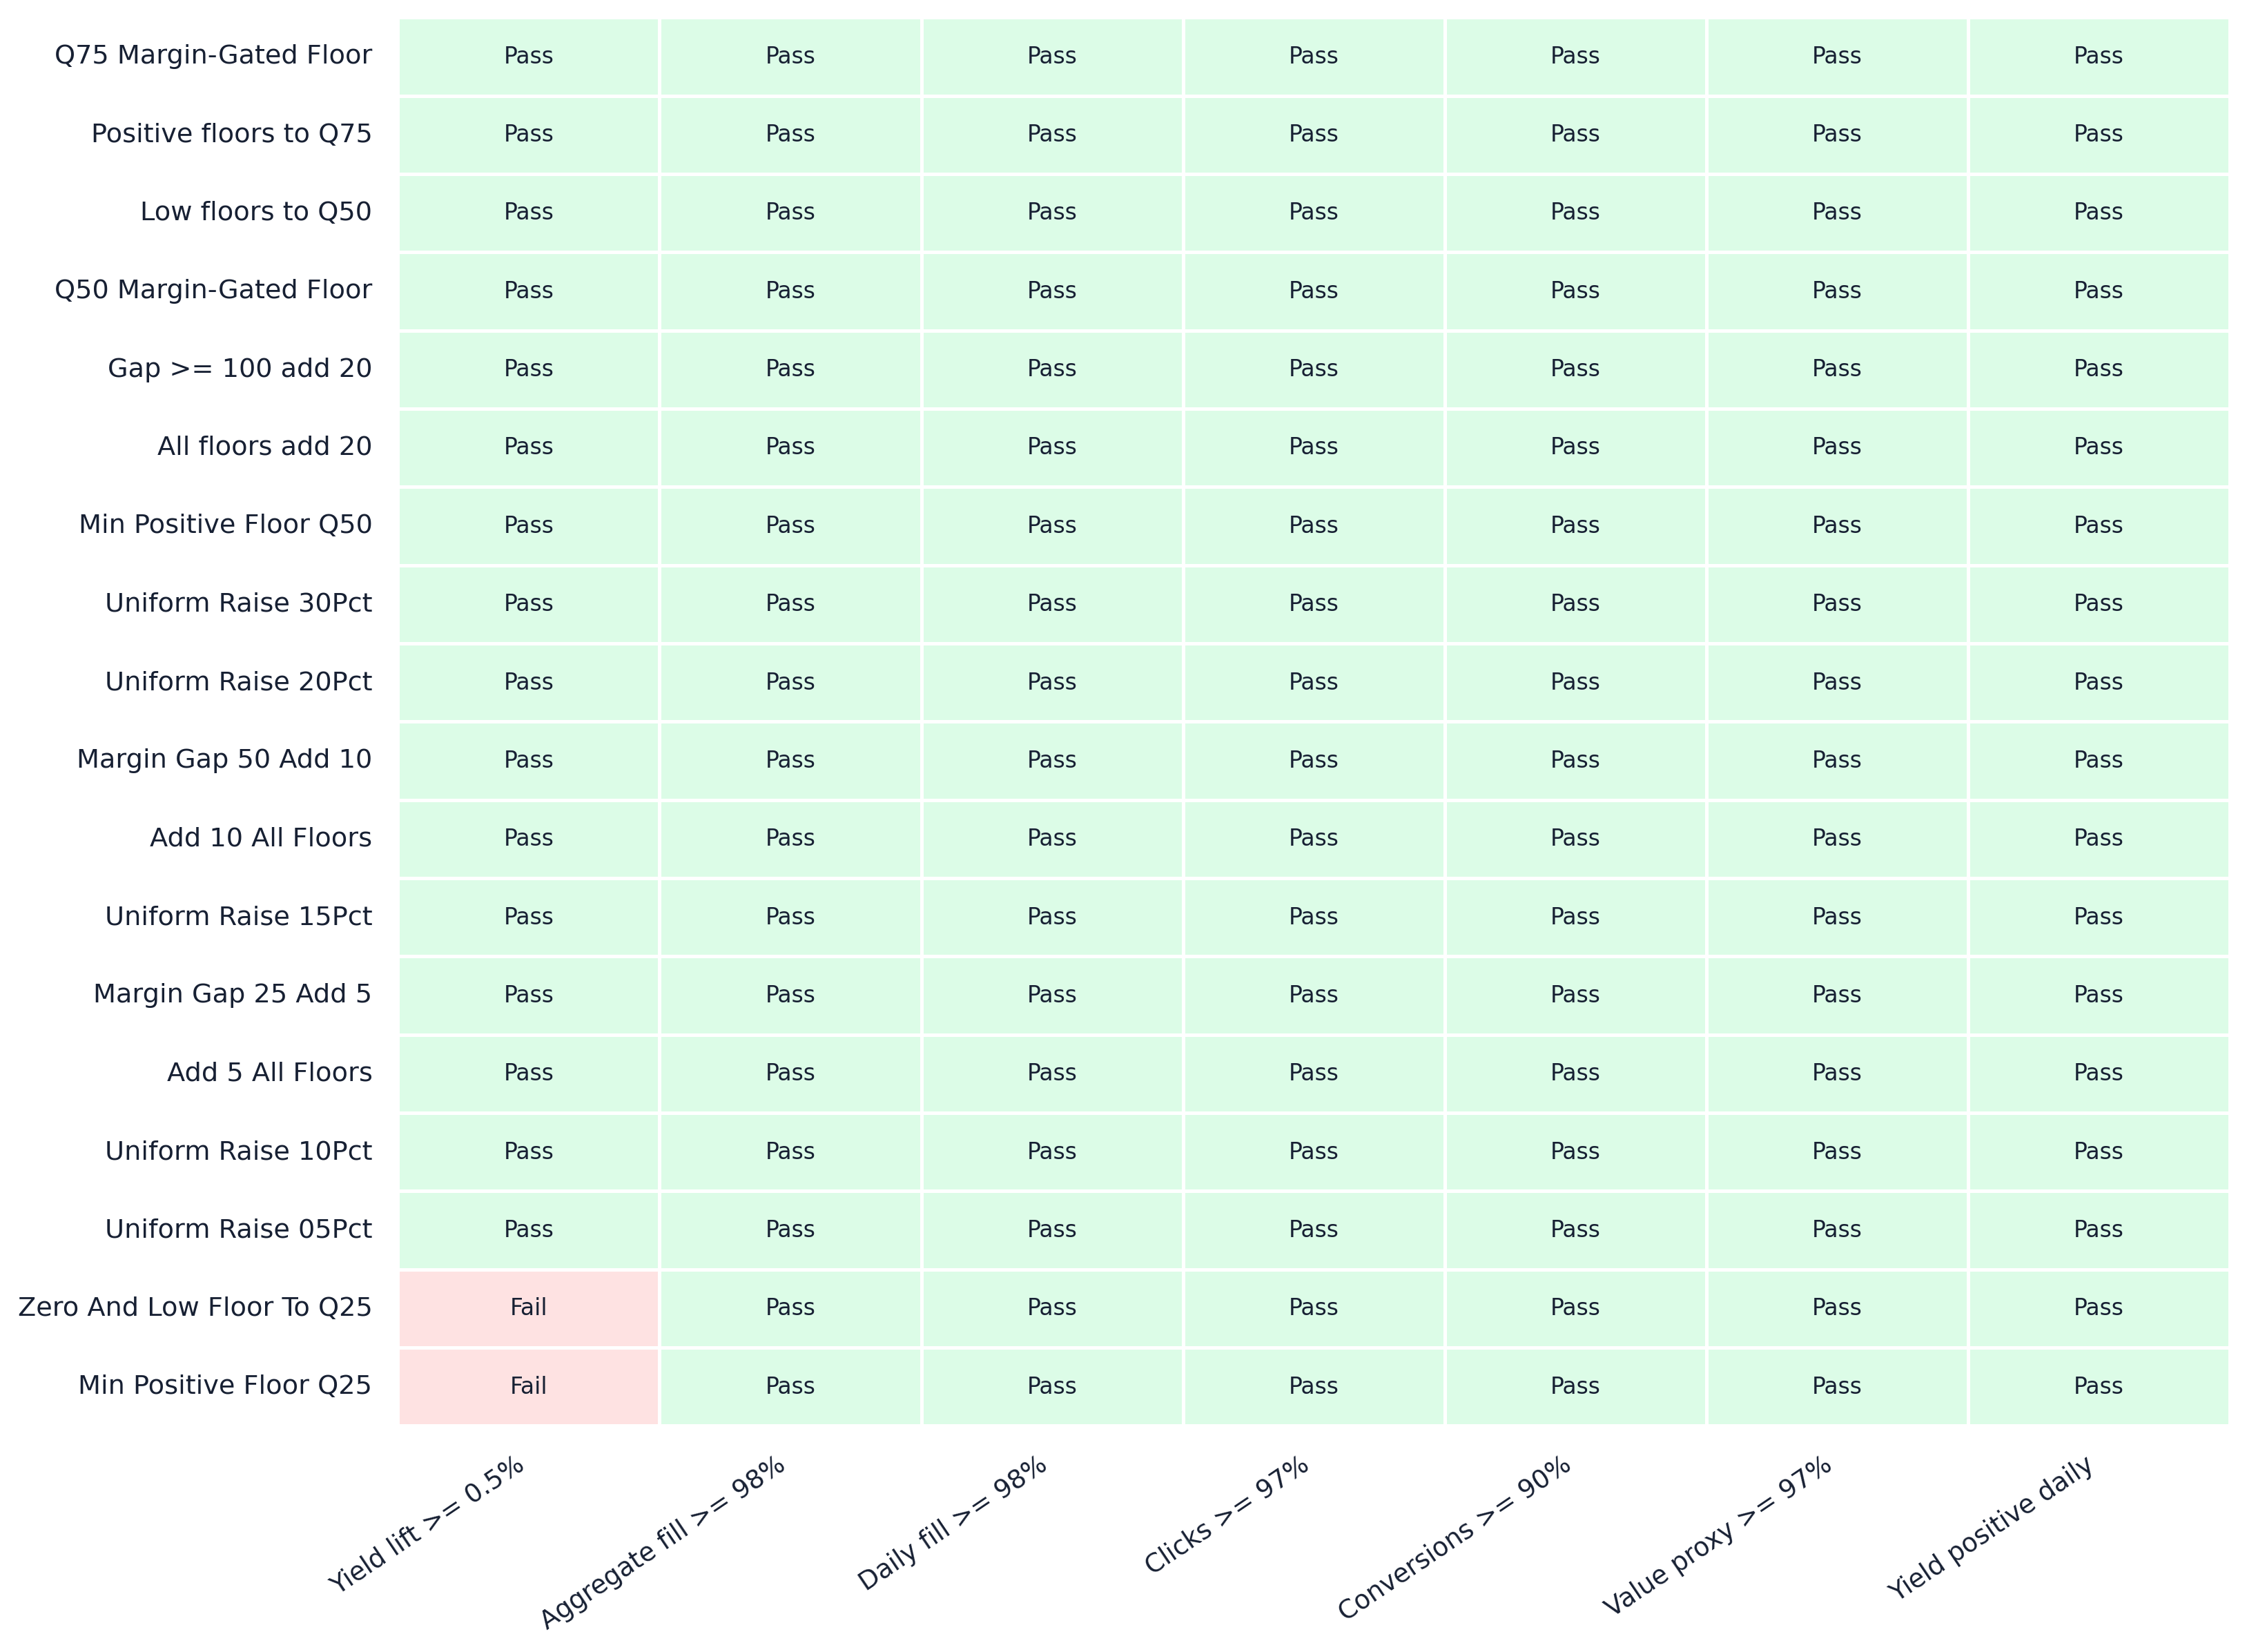

guardrail_label,Aggregate fill >= 98%,Clicks >= 97%,Conversions >= 90%,Daily fill >= 98%,Value proxy >= 97%,Yield lift >= 0.5%,Yield positive daily
policy_id,,,,,,,
add_10_all_floors,Pass,Pass,Pass,Pass,Pass,Pass,Pass
add_20_all_floors,Pass,Pass,Pass,Pass,Pass,Pass,Pass
add_5_all_floors,Pass,Pass,Pass,Pass,Pass,Pass,Pass
hybrid_q50_if_gap_50,Pass,Pass,Pass,Pass,Pass,Pass,Pass
hybrid_q75_if_gap_100,Pass,Pass,Pass,Pass,Pass,Pass,Pass
margin_gap_100_add_20,Pass,Pass,Pass,Pass,Pass,Pass,Pass
margin_gap_25_add_5,Pass,Pass,Pass,Pass,Pass,Pass,Pass
margin_gap_50_add_10,Pass,Pass,Pass,Pass,Pass,Pass,Pass
min_positive_floor_q25,Pass,Pass,Pass,Pass,Pass,Fail,Pass


In [8]:
guardrail_matrix = repository.read_csv("reserve_policy_guardrail_matrix.csv")

matrix_preview = (
    guardrail_matrix
    .query("policy_id != 'logged_floor_status_quo'")
    .pivot_table(index="policy_id", columns="guardrail_label", values="passed", aggfunc="first")
    .replace({True: "Pass", False: "Fail"})
)

renderer = FigureRenderer(repository, paths.figure_dir, PaperConfig(), progress=progress)
guardrail_matrix_path = renderer.plot_guardrail_matrix()
print(f"Wrote guardrail policy matrix to {guardrail_matrix_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(guardrail_matrix_path)))

matrix_preview



## Reserve-Policy Tradeoff Frontier

The frontier figure plots replay yield lift against the share of opportunities whose floor is changed. This shows the shape of the policy problem. If every attractive policy changed almost every auction, the intervention would be broad and potentially risky. If a policy generates yield lift by changing a smaller, margin-selected subset, it is easier to motivate as an experiment candidate.

Marker size reflects how many guardrails the policy passes. The priority policy is highlighted in red. The purpose of this figure is not to prove launch readiness; it creates the candidate set for deeper analysis.



Wrote Figure 5 to artifacts/figures/06_reserve_policy_tradeoff_frontier.png


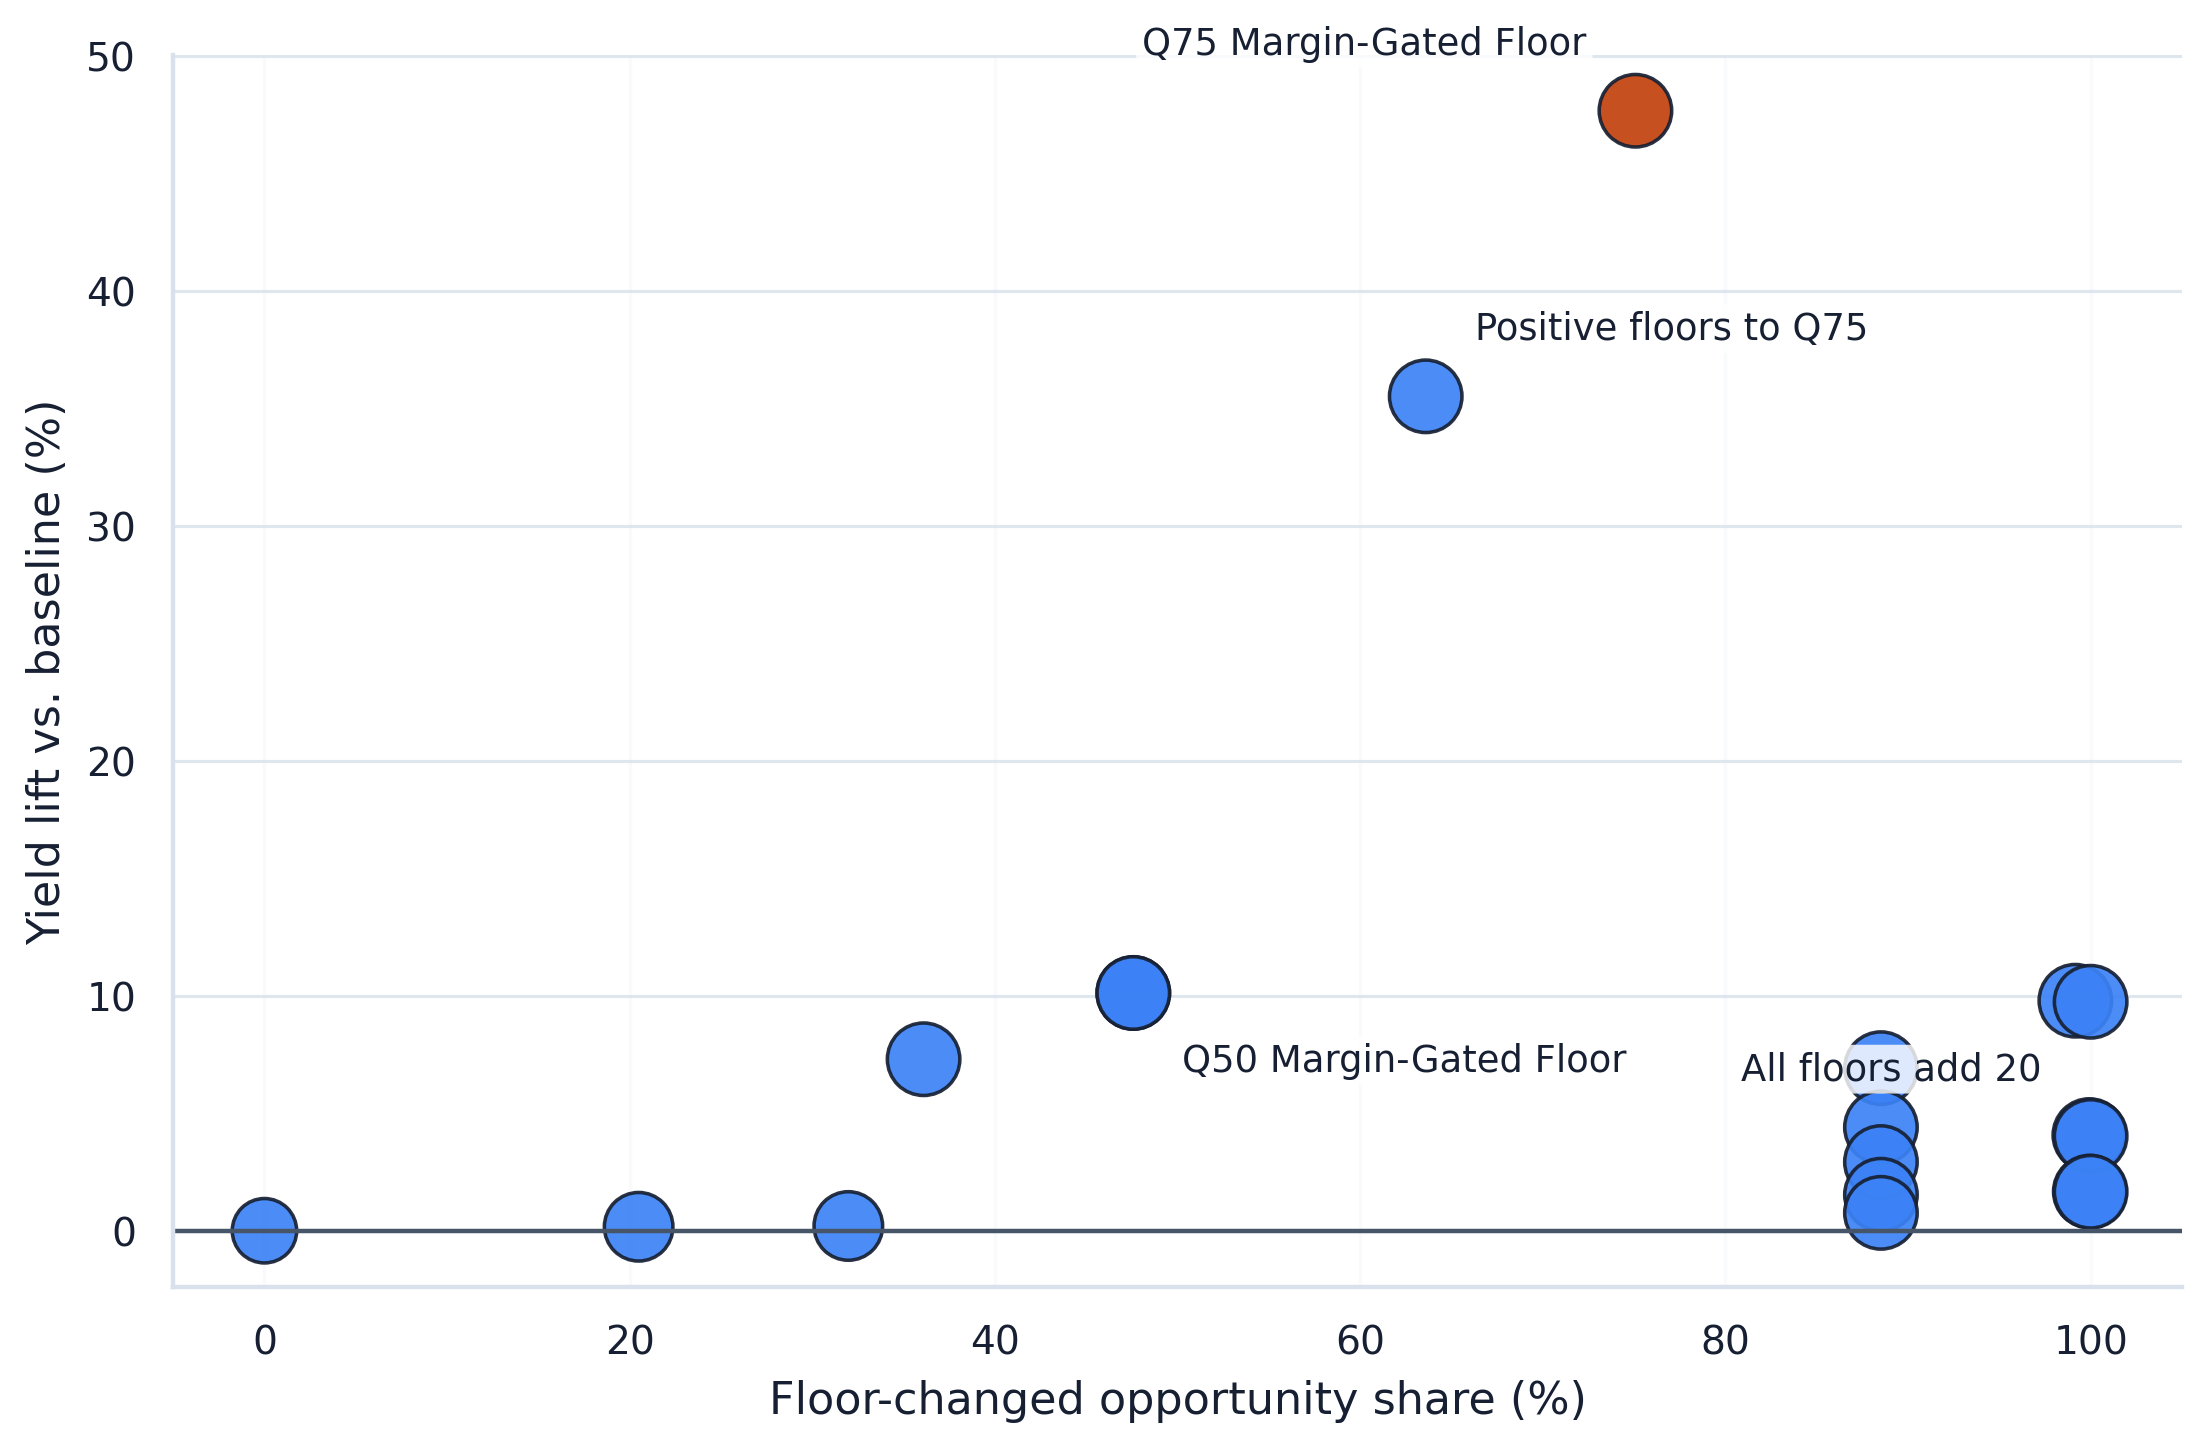

In [9]:
renderer = FigureRenderer(repository, paths.figure_dir, PaperConfig(), progress=progress)
frontier_path = renderer.plot_frontier()
print(f"Wrote Figure 5 to {frontier_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(frontier_path)))


## Shortlist Daily Stability

The daily-stability figure asks whether the shortlisted policies have a repeatable pattern over the observed Season 2 days. This is a simple but important operational check. A replay winner that only wins on one unusual day is a weak experiment candidate, even if its aggregate lift is large. Conversely, a policy that produces positive replay lift across all observed days is a stronger candidate for OPE diagnostics and validation planning.



Wrote Figure 6 to artifacts/figures/06_shortlist_daily_stability.png


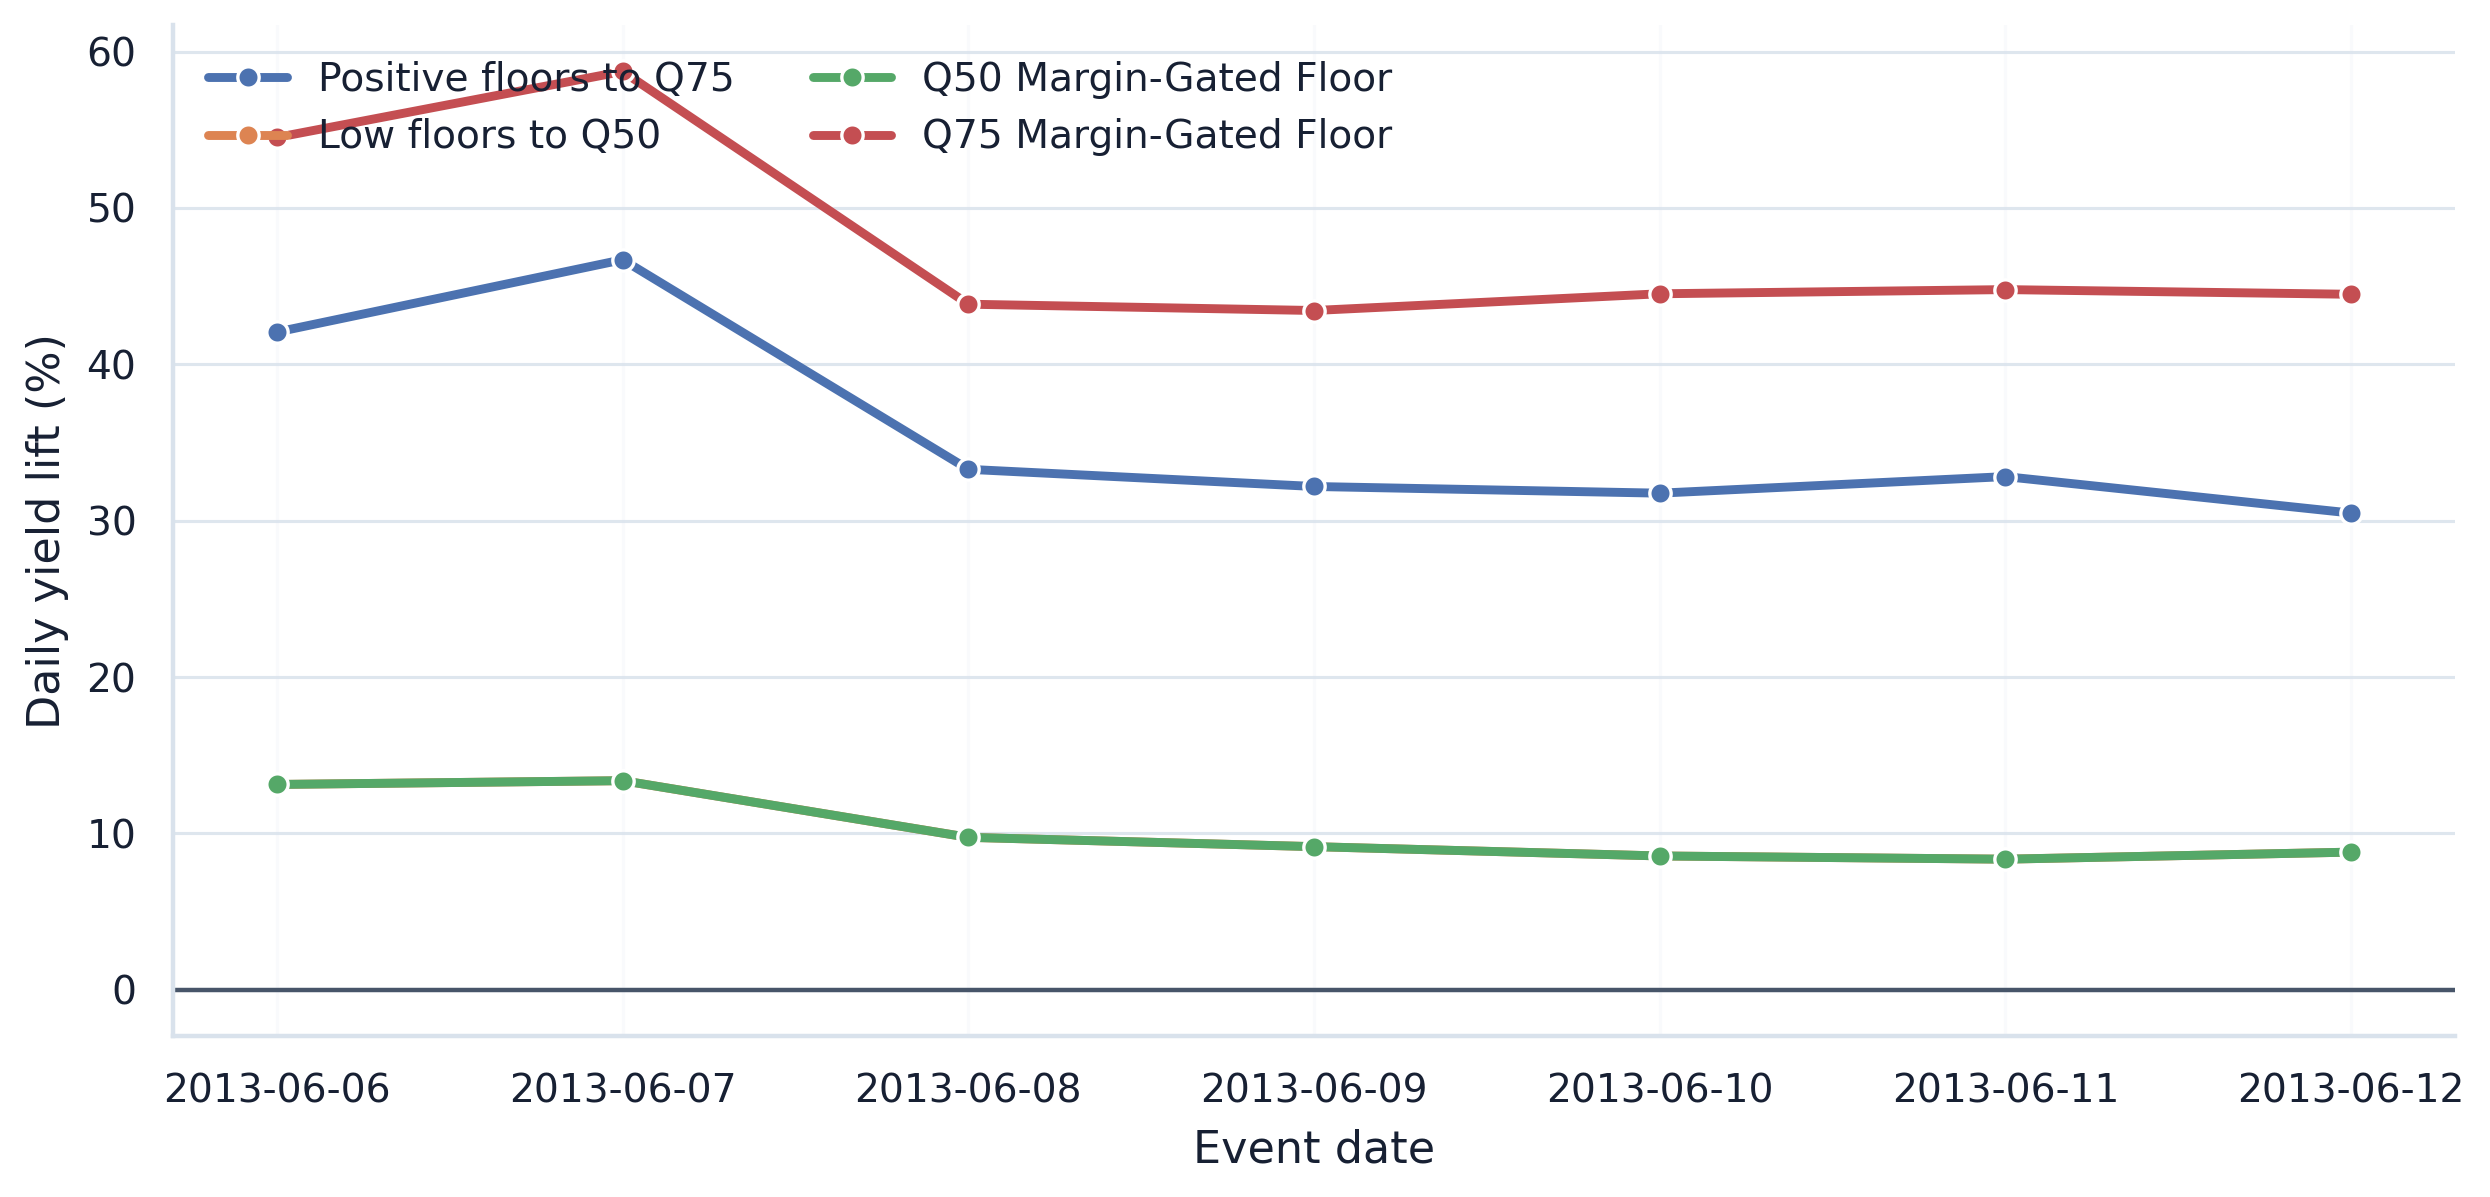

In [10]:
daily_stability_path = renderer.plot_daily_stability()
print(f"Wrote Figure 6 to {daily_stability_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(daily_stability_path)))


In [11]:
daily_summary = (
    daily.merge(registry_labels, on="policy_id", how="left")
    .loc[lambda d: d["policy_id"].isin(shortlist["policy_id"])]
    .groupby(["policy_number", "policy_label", "policy_id"], as_index=False)
    .agg(
        days_observed=("event_date", "nunique"),
        min_daily_yield_lift=("pct_delta_yield_per_opportunity_vs_daily_baseline", "min"),
        median_daily_yield_lift=("pct_delta_yield_per_opportunity_vs_daily_baseline", "median"),
        max_daily_yield_lift=("pct_delta_yield_per_opportunity_vs_daily_baseline", "max"),
        min_daily_fill_retention=("retained_impression_share", "min"),
    )
    .sort_values("median_daily_yield_lift", ascending=False)
)
daily_summary


,policy_number,policy_label,policy_id,days_observed,min_daily_yield_lift,median_daily_yield_lift,max_daily_yield_lift,min_daily_fill_retention
8,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,7,0.434379,0.445079,0.587269,1.000000
2,P11,Min Positive Floor Q75,min_positive_floor_q75,7,0.304854,0.328184,0.466869,1.000000
6,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,7,0.085508,0.098543,0.111918,1.000000
15,P8,Add 20 All Floors,add_20_all_floors,7,0.084929,0.098436,0.111276,0.999641
7,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,7,0.083526,0.091541,0.133728,1.000000
3,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,7,0.083526,0.091541,0.133728,1.000000
12,P5,Uniform Raise 30Pct,uniform_raise_30pct,7,0.062366,0.071038,0.076202,0.997172
1,P10,Min Positive Floor Q50,min_positive_floor_q50,7,0.054622,0.066328,0.105721,1.000000
11,P4,Uniform Raise 20Pct,uniform_raise_20pct,7,0.038312,0.045459,0.049416,0.999089
5,P15,Margin Gap 50 Add 10,margin_gap_50_add_10,7,0.035087,0.039677,0.048909,1.000000


## Interpretation for the Paper

This notebook supplies the first policy-relevant empirical result. The replay frontier screens the catalog for policies with nontrivial yield upside under the logged-bid replay contract. The guardrails and daily-stability view then prevent the analysis from treating aggregate yield lift as sufficient evidence. A policy moves forward only if it looks attractive on average and does not obviously fail delivery, value, or temporal-stability checks.

The correct interpretation remains conservative. Replay estimates a finite-population mechanical counterfactual under fixed bids and fixed participation. It is strong evidence for screening, but not a live marketplace treatment effect. The next notebooks should therefore ask whether the shortlisted policies have enough support for model-assisted OPE, whether the ranking is robust to uncertainty and heterogeneity, and whether the leading policy transfers to the Season 3 holdout window.
